<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">REDES NEURONALES CONVOLUCIONALES</strong><br>
  <strong style="font-size: 24px;">PyTorch</strong>
</div>

# Filtros de ejemplo aprendidos por Krizhevsky et al.

Cada uno de los 96 filtros mostrados aquí tiene un tamaño de [11 x 11 x 3], y cada uno se comparte entre las 55 x 55 neuronas en una rebanada de profundidad.

En las Redes Neuronales Convolucionales (CNNs), los filtros (o kernels) se aprenden durante el entrenamiento y capturan características como bordes, colores y texturas.

Shape of filters: torch.Size([96, 3, 11, 11])


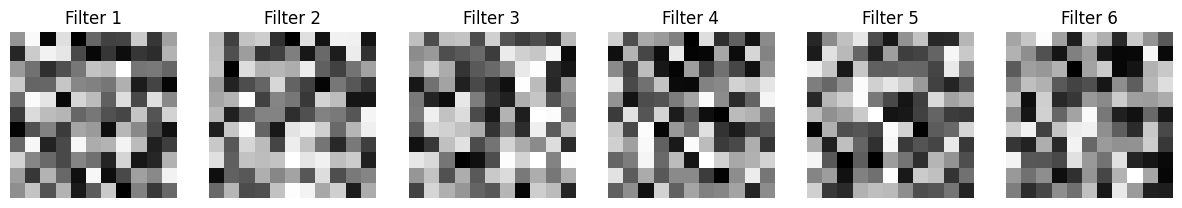

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Definición de una capa convolucional similar a la usada en AlexNet
conv = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4)

# Inicialización aleatoria de los pesos (normal en PyTorch)
filters = conv.weight.data.clone()

print("Shape of filters:", filters.shape)  # (96, 3, 11, 11)

# Visualización de los primeros 6 filtros (proyectando solo el canal rojo)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(filters[i, 0].detach().numpy(), cmap="gray")
    axes[i].set_title(f"Filter {i+1}")
    axes[i].axis("off")

plt.show()


# Capa **Convolucional**

## Ejemplo 1

Para hacer más concreta la explicación, se expresan las mismas ideas en código y con un ejemplo específico.

Se supone que el volumen de entrada es un arreglo de numpy $X$. Entonces:

- Una **columna de profundidad (o fibra)** en la posición $(x,y)$ corresponde a las activaciones $X[x,y,:]$.  
- Una **rebanada de profundidad**, o de manera equivalente un **mapa de activación** en la profundidad $d$, corresponde a las activaciones $X[:,:,d]$.


Se considera que el volumen de entrada $X$ tiene forma $(11, 11, 4)$.  
Además, se establece que no se utiliza relleno con ceros ($P=0$), que el tamaño del filtro es $F=5$, y que el paso es $S=2$.  

El volumen de salida tendría un tamaño espacial dado por:

$$
\frac{(11 - 5)}{2} + 1 = 4
$$

lo que genera un volumen con ancho y alto de $4$.  

El mapa de activación en el volumen de salida (denotado por $V$) se calcularía de la siguiente manera (aquí solo se muestran algunos elementos):


In [2]:
import numpy as np

# Volumen de entrada: forma (11,11,4)
X = np.random.randn(11, 11, 4)
print("Tamaño de X:",X.shape)

# Filtro W0: forma (5,5,4), sesgo b0
W0 = np.random.randn(5, 5, 4)
b0 = np.random.randn()

# Volumen de salida V: forma (4,4,2) para dos filtros W0 y W1
V = np.zeros((4, 4, 2))

# Primer mapa de activación usando W0
V[0,0,0] = np.sum(X[:5, :5, :] * W0) + b0
V[1,0,0] = np.sum(X[2:7, :5, :] * W0) + b0
V[2,0,0] = np.sum(X[4:9, :5, :] * W0) + b0
V[3,0,0] = np.sum(X[6:11, :5, :] * W0) + b0

print("Primer mapa de activación (resultados parciales):")
print(V[:,:,0])


Tamaño de X: (11, 11, 4)
Primer mapa de activación (resultados parciales):
[[ -0.25766952   0.           0.           0.        ]
 [-17.03576563   0.           0.           0.        ]
 [ -1.76484393   0.           0.           0.        ]
 [  3.90594492   0.           0.           0.        ]]


In [3]:
# Segundo filtro W1: forma (5,5,4), sesgo b1
W1 = np.random.randn(5, 5, 4)
b1 = np.random.randn()

# Segundo mapa de activación usando W1
V[0,0,1] = np.sum(X[:5, :5, :] * W1) + b1
V[1,0,1] = np.sum(X[2:7, :5, :] * W1) + b1
V[2,0,1] = np.sum(X[4:9, :5, :] * W1) + b1
V[3,0,1] = np.sum(X[6:11, :5, :] * W1) + b1
V[0,1,1] = np.sum(X[:5, 2:7, :] * W1) + b1  # desplazamiento en y
V[2,3,1] = np.sum(X[4:9, 6:11, :] * W1) + b1  # desplazamiento en x e y

print("Segundo mapa de activación (resultados parciales):")
print(V[:,:,1])


Segundo mapa de activación (resultados parciales):
[[13.45209114 10.35981727  0.          0.        ]
 [-1.86526838  0.          0.          0.        ]
 [15.40486029  0.          0.         18.34459053]
 [16.97822449  0.          0.          0.        ]]


Una **fibra** o columna de profundidad en la posición ($x,y$), sería


In [4]:
x=5
y=6

print("Valor de la profundidad:",X[x,y,:].shape)
print(f"Fibre o columna de profundidad en la prosición ({x},{y}):")
print(X[x,y,:])

Valor de la profundidad: (4,)
Fibre o columna de profundidad en la prosición (5,6):
[-1.65295183  0.71464184 -0.73562485 -0.91610063]


## Ejemplo 2 - **CAPA CONVOLUCIONAL**

**Proceso de Convolución en 2D Multi-Canal**

La **convolución** es una operación fundamental en redes neuronales convolucionales (CNN) que permite extraer patrones locales de una entrada, como bordes o texturas. En el código proporcionado, la convolución se realiza en varios pasos principales:

1. **Rotación del filtro (máscara)**  
   - La convolución matemática requiere rotar el filtro 180° antes de aplicarlo.  
   - En el código, esto se hace mediante:  
     ```python
     K_rot = np.rot90(K, 2, axes=(0,1))
     ```

2. **Aplicación de padding**  
   - Se agregan ceros alrededor de la entrada para controlar el tamaño de la salida y preservar los bordes.  
   - En el código:  
     ```python
     X_pad = np.pad(X, ((padding,padding),(padding,padding),(0,0)), mode='constant')
     ```

3. **Recorrido de la imagen (desplazamiento del filtro)**  
   - El filtro se mueve sobre la entrada con un determinado `stride` (paso), cubriendo todas las regiones posibles.  
   - Esto se implementa con los bucles `for i in range(H_out)` y `for j in range(W_out)`.

4. **Producto elemento a elemento y suma local**  
   - Para cada posición del filtro, se realiza un **producto de Hadamard local** entre la región de la entrada y el filtro rotado, y luego se suman todos los valores para producir un solo número en la salida.  
   - En el código:  
     ```python
     out[i,j] = np.sum(region * K_rot) + bias
     ```

5. **Agregado del bias**  
   - Se suma un valor escalar `bias` a cada elemento de la salida para ajustar la activación.  
   - Esto se realiza al mismo tiempo que la suma de productos, en la línea anterior.

6. **Construcción del mapa de salida**  
   - El resultado final es una matriz 2D que representa la activación de la convolución en cada posición de la entrada.  
   - El tamaño de la salida depende de la dimensión de la entrada, el tamaño del filtro, el padding y el stride.

---

En resumen, el código implementa **la convolución 2D multi-canal** siguiendo exactamente los pasos de la definición matemática: rotación del filtro, desplazamiento sobre la entrada, multiplicación elemento a elemento, suma local y adición del bias.

---
**Definición de imagen y filtros**

In [5]:
import numpy as np

# -----------------------------
# Imagen 5x5x3
# -----------------------------
canal0 = np.array([
    [0, 2, 1, 0, 2],
    [2, 2, 0, 0, 1],
    [1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 2, 0, 1, 0]
])

canal1 = np.array([
    [0, 1, 1, 0, 2],
    [1, 1, 1, 1, 1],
    [0, 1, 0, 0, 2],
    [1, 2, 0, 0, 0],
    [2, 1, 2, 0, 0]
])

canal2 = np.array([
    [2, 1, 0, 0, 1],
    [1, 1, 0, 0, 0],
    [2, 2, 1, 0, 1],
    [2, 2, 1, 2, 2],
    [0, 1, 0, 0, 0]
])

# Construcción del volumen 5x5x3
X = np.stack([canal0, canal1, canal2], axis=2)



# Obtener la cantidad de matrices en el tercer eje
_, _, p = X.shape
print("Tamaño de la Imagen: ", X.shape)
# Imprimir cada matriz del tercer eje en una sola línea
# for k in range(p):
#     print(f"\nImagen[:,:,{k}]:\n",X[:,:,k])
# print()  # salto de línea final


# -----------------------------
# Filtros w0 y w1 (3x3x3)
# -----------------------------
w00 = np.array([
    [1, -1, -1],
     [-1, -1, 1],
     [ -1,  1,  0],
])

w01 = np.array([    
    [ 0,  0,  0],
     [ -1,  0, 1],
     [ -1, 1, 1],
])

w02 = np.array([
    [ 0, 1,  0],
     [ 1,  0,  0],
     [ 0,  0, 0]
])

w10 = np.array([
    [ 0,  1,  1],
     [0,  -1, 0],
     [ 1,  1,  0],
])

w11 = np.array([
    [ 0,  1,  1],
     [0,  -1,  0],
     [ -1, 0, -1],
])

w12 = np.array([
    [ 1,  0, -1],
     [1,  0,  1],
     [ 1, 1,  1]
])


# Construcción del volumen 5x5x3
w0 = np.stack([w00, w01, w02], axis=2)
w1 = np.stack([w10, w11, w12], axis=2)


# -----------------------------
# Parámetros
# -----------------------------
S = 2
P = 1
b0 = 1
b1 = 0


# -----------------------------
# Mostrar Datos
# -----------------------------

# Obtener la cantidad de matrices en el tercer eje
_, _, p = w0.shape
print("\nTamaño del filtro w0: ", w0.shape)
# Imprimir cada matriz del tercer eje en una sola línea
# for k in range(p):
#     print(f"\nw0[:,:,{k}]:\n",w0[:,:,k])
# print()  # salto de línea final


# Obtener la cantidad de matrices en el tercer eje
_, _, p = w1.shape
print("\nTamaño del filtro w1: ", w1.shape)
# Imprimir cada matriz del tercer eje en una sola línea
# for k in range(p):
#     print(f"\nw1[:,:,{k}]:\n",w1[:,:,k])
# print()  # salto de línea final

Tamaño de la Imagen:  (5, 5, 3)

Tamaño del filtro w0:  (3, 3, 3)

Tamaño del filtro w1:  (3, 3, 3)


---
**Convolución 2D multi-canal real**, es decir con rotación de los filtros

In [6]:
import numpy as np

# -----------------------------
# Función para "convolución 2D multi-canal real"
# -----------------------------
def conv2d_real(X, K, bias=0, stride=1, padding=0):
    """
    X: input de tamaño (H, W, C)
    K: kernel/filtro de tamaño (FH, FW, C)
    bias: sesgo escalar
    stride: paso de desplazamiento
    padding: cantidad de ceros alrededor de la imagen
    """
    H, W_, C = X.shape
    FH, FW, Ck = K.shape
    assert C == Ck, "Los canales de la entrada y del filtro deben coincidir"

    # Rotamos el filtro 180° (rotación horizontal + vertical)
    K_rot = np.rot90(K, 2, axes=(0,1))

    # Padding
    X_pad = np.pad(X, ((padding,padding),(padding,padding),(0,0)), mode='constant')

    # Dimensiones de salida
    H_out = (H + 2*padding - FH)//stride + 1
    W_out = (W_ + 2*padding - FW)//stride + 1

    # Salida
    out = np.zeros((H_out, W_out), dtype=float)

    # Recorremos la imagen
    for i in range(H_out):
        for j in range(W_out):
            # Región local de la imagen
            region = X_pad[i*stride:i*stride+FH, j*stride:j*stride+FW, :]
            # Producto elemento a elemento y suma sobre la ventana (con filtro rotado)
            out[i,j] = np.sum(region * K_rot) + bias

    return out

# -----------------------------
# Aplicar Convolución real
# -----------------------------
out_w0 = conv2d_real(X, w0, b0, stride=S, padding=P)
out_w1 = conv2d_real(X, w1, b1, stride=S, padding=P)

# -----------------------------
# Mostrar resultados
# -----------------------------
print("Resultado final con w0:")
print(out_w0)

print("\nResultado final con w1:")
print(out_w1)


Resultado final con w0:
[[ 0.  1. -2.]
 [ 2.  3.  6.]
 [-3.  6.  2.]]

Resultado final con w1:
[[ 5.  2. -1.]
 [ 9.  3. -4.]
 [ 0.  3.  4.]]


---
#### Convolución **sin rotar** las máscaras 180 grados.

In [7]:
import numpy as np

# -----------------------------
# Función para "convolución 2D multi-canal"
# -----------------------------
def conv2d(X, K, bias=0, stride=1, padding=0):
    """
    X: input de tamaño (H, W, C)
    K: kernel/filtro de tamaño (FH, FW, C)
    bias: sesgo escalar
    stride: paso de desplazamiento
    padding: cantidad de ceros alrededor de la imagen
    """
    H, W_, C = X.shape
    FH, FW, Ck = K.shape
    assert C == Ck, "Los canales de la entrada y del filtro deben coincidir"

    # Padding
    X_pad = np.pad(X, ((padding,padding),(padding,padding),(0,0)), mode='constant')

    # Dimensiones de salida
    H_out = (H + 2*padding - FH)//stride + 1
    W_out = (W_ + 2*padding - FW)//stride + 1

    # Salida
    out = np.zeros((H_out, W_out), dtype=float)

    # Recorremos la imagen
    for i in range(H_out):
        for j in range(W_out):
            # Región local de la imagen
            region = X_pad[i*stride:i*stride+FH, j*stride:j*stride+FW, :]
            # Producto punto sobre la ventana local (Hadamard + suma)
            out[i,j] = np.sum(region * K) + bias

    return out

# -----------------------------
# Aplicar Convolucion
# -----------------------------

out_w0 = conv2d(X, w0, b0, stride=S, padding=P)
out_w1 = conv2d(X, w1, b1, stride=S, padding=P)

# -----------------------------
# Mostrar resultados
# -----------------------------
print("Resultado final con w0:")
print(out_w0)

print("\nResultado final con w1:")
print(out_w1)


Resultado final con w0:
[[ 8. -3.  0.]
 [ 2.  1.  0.]
 [ 5.  0.  2.]]

Resultado final con w1:
[[ 4.  0. -4.]
 [ 8.  8.  4.]
 [-1.  0.  2.]]


---

**Correlación cruzada**

Al usar la función scipy.signal.correlate se obtiene la correlación cruzada, que es lo que normalmente se usa en CNNs (equivalente a la convolución sin rotar el filtro).

In [8]:
import numpy as np
from scipy.signal import correlate  # correlación cruzada (similar a conv2d en CNNs)

# -----------------------------
# Función para aplicar convolución usando librería
# -----------------------------
def conv2d_lib(X, K, bias=0, stride=1, padding=0):
    """
    X: input de tamaño (H, W, C)
    K: kernel/filtro de tamaño (FH, FW, C)
    bias: sesgo escalar
    stride: paso de desplazamiento
    padding: cantidad de ceros alrededor de la imagen
    """
    H, W_, C = X.shape
    FH, FW, Ck = K.shape
    assert C == Ck, "Los canales de la entrada y del filtro deben coincidir"

    # Padding
    X_pad = np.pad(X, ((padding,padding),(padding,padding),(0,0)), mode='constant')

    # Inicializamos la salida
    H_out = (H + 2*padding - FH)//stride + 1
    W_out = (W_ + 2*padding - FW)//stride + 1
    out = np.zeros((H_out, W_out), dtype=float)

    # Aplicamos correlación cruzada por canal y sumamos
    for c in range(C):
        out += correlate(X_pad[:,:,c], K[:,:,c], mode='valid')[::stride, ::stride]

    # Agregamos bias
    out += bias
    return out

# -----------------------------
# Aplicar Convolución
# -----------------------------
out_w0 = conv2d_lib(X, w0, b0, stride=S, padding=P)
out_w1 = conv2d_lib(X, w1, b1, stride=S, padding=P)

# -----------------------------
# Mostrar resultados
# -----------------------------
print("Resultado final con w0:")
print(out_w0)

print("\nResultado final con w1:")
print(out_w1)


Resultado final con w0:
[[ 8. -3.  0.]
 [ 2.  1.  0.]
 [ 5.  0.  2.]]

Resultado final con w1:
[[ 4.  0. -4.]
 [ 8.  8.  4.]
 [-1.  0.  2.]]


# Capa **Pooling**

## Explicación

Calcula el tamaño de salida:

$$
W_2 = \frac{W_1 - F}{S} + 1, \quad H_2 = \frac{H_1 - F}{S} + 1
$$

Se recorre la imagen con ventanas de tamaño $F \times F$ y stride $S$.

Se calculan distintos tipos de pooling:

- **Max Pooling**: toma el valor máximo en la ventana.
- **Average Pooling**: calcula el promedio de los valores en la ventana.
- **L2-norm Pooling**: calcula la raíz cuadrada de la suma de cuadrados.

Devuelve tres matrices con el tamaño de salida adecuado.


In [9]:
import numpy as np

# -----------------------------
# Función de Pooling
# -----------------------------
def pooling(X, F=2, S=2):
    """
    X: imagen de entrada de tamaño (H1, W1) o (H1, W1, C)
    F: tamaño de la ventana de pooling
    S: stride (desplazamiento)
    
    Devuelve tres matrices (Max, Average, L2-norm) de tamaño (H2, W2, C)
    """
    # Si la imagen es 2D, añadimos un canal
    if X.ndim == 2:
        X = X[:, :, np.newaxis]
    
    H1, W1, C = X.shape
    H2 = (H1 - F)//S + 1
    W2 = (W1 - F)//S + 1
    
    # Inicializamos las matrices de salida
    max_pool = np.zeros((H2, W2, C))
    avg_pool = np.zeros((H2, W2, C))
    l2_pool = np.zeros((H2, W2, C))
    
    # Recorremos cada canal
    for c in range(C):
        for i in range(H2):
            for j in range(W2):
                # Región local
                region = X[i*S:i*S+F, j*S:j*S+F, c]
                
                # Max Pooling
                max_pool[i,j,c] = np.max(region)
                
                # Average Pooling
                avg_pool[i,j,c] = np.mean(region)
                
                # L2-norm Pooling
                l2_pool[i,j,c] = np.sqrt(np.sum(region**2))
    
    # Si la entrada era 2D, quitamos el eje del canal
    if max_pool.shape[2] == 1:
        max_pool = max_pool[:,:,0]
        avg_pool = avg_pool[:,:,0]
        l2_pool = l2_pool[:,:,0]
    
    return max_pool, avg_pool, l2_pool

In [10]:
# -----------------------------
# Imagen y Parámetros 
# -----------------------------

# Imagen de entrada (puede ser aleatoria)
H1, W1 = 4, 4
X = np.array([
    [1, 1, 2, 4],
    [5, 6, 7, 8],
    [3, 2, 1, 0],
    [1, 2, 3, 4]
])

# Parámetros
F = 2
S = 1


# -----------------------------
# Ejemplo de uso
# -----------------------------

# Aplicar pooling
max_out, avg_out, l2_out = pooling(X, F, S)

# Mostrar resultados
print(f"F={F}, S={S}")
print("Imagen de entrada:\n", X)
print("\nMax Pooling:\n", max_out)
print("\nAverage Pooling:\n", avg_out)
print("\nL2-norm Pooling:\n", l2_out)

F=2, S=1
Imagen de entrada:
 [[1 1 2 4]
 [5 6 7 8]
 [3 2 1 0]
 [1 2 3 4]]

Max Pooling:
 [[6. 7. 8.]
 [6. 7. 8.]
 [3. 3. 4.]]

Average Pooling:
 [[3.25 4.   5.25]
 [4.   4.   4.  ]
 [2.   2.   2.  ]]

L2-norm Pooling:
 [[ 7.93725393  9.48683298 11.53256259]
 [ 8.60232527  9.48683298 10.67707825]
 [ 4.24264069  4.24264069  5.09901951]]


In [11]:
# Parámetros
F = 2
S = 2


# -----------------------------
# Ejemplo de uso
# -----------------------------

# Aplicar pooling
max_out, avg_out, l2_out = pooling(X, F, S)

# Mostrar resultados
print(f"F={F}, S={S}")
print("Imagen de entrada:\n", X)
print("\nMax Pooling:\n", max_out)
print("\nAverage Pooling:\n", avg_out)
print("\nL2-norm Pooling:\n", l2_out)

F=2, S=2
Imagen de entrada:
 [[1 1 2 4]
 [5 6 7 8]
 [3 2 1 0]
 [1 2 3 4]]

Max Pooling:
 [[6. 8.]
 [3. 4.]]

Average Pooling:
 [[3.25 5.25]
 [2.   2.  ]]

L2-norm Pooling:
 [[ 7.93725393 11.53256259]
 [ 4.24264069  5.09901951]]


In [12]:
# Parámetros
F = 2
S = 3


# -----------------------------
# Ejemplo de uso
# -----------------------------

# Aplicar pooling
max_out, avg_out, l2_out = pooling(X, F, S)

# Mostrar resultados
print(f"F={F}, S={S}")
print("Imagen de entrada:\n", X)
print("\nMax Pooling:\n", max_out)
print("\nAverage Pooling:\n", avg_out)
print("\nL2-norm Pooling:\n", l2_out)

F=2, S=3
Imagen de entrada:
 [[1 1 2 4]
 [5 6 7 8]
 [3 2 1 0]
 [1 2 3 4]]

Max Pooling:
 [[6.]]

Average Pooling:
 [[3.25]]

L2-norm Pooling:
 [[7.93725393]]


## Reducción por incremento de **S**

In [13]:
# -----------------------------
# Imagen y Parámetros 
# -----------------------------

# Imagen de entrada (puede ser aleatoria)
H1, W1 = 11, 11
X = np.random.randint(0, 10, (H1, W1))

# Parámetros
F = 2
S = 4


# -----------------------------
# Ejemplo de uso
# -----------------------------

print("Tamaño de la imagen de entrada:", X.shape)
for i in range(S):
    # Aplicar pooling
    max_out = pooling(X, F, S=i+2)

    # Mostrar resultados
    print(f"\nF={F}, S={i+2}")
    print("Tamaño de la resultante del Pooling:", max_out[2].shape)
    

Tamaño de la imagen de entrada: (11, 11)

F=2, S=2
Tamaño de la resultante del Pooling: (5, 5)

F=2, S=3
Tamaño de la resultante del Pooling: (4, 4)

F=2, S=4
Tamaño de la resultante del Pooling: (3, 3)

F=2, S=5
Tamaño de la resultante del Pooling: (2, 2)


# Ejemplo CNN usando PyTorch

In [14]:
#!pip install torchinfo
#!pip install torchviz
#!pip install torchsummary

In [15]:
# ============================================
# Importar librerías
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchinfo import summary  # mejor que torchsummary

In [16]:
# ============================================
# Preparar los datos (MNIST)
# ============================================
transform = transforms.Compose([
    transforms.ToTensor(),              # Convertir a tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalizar valores entre -1 y 1
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [17]:
# ============================================
# Mostrar información de los datos
# ============================================
print("Cantidad de imágenes de entrenamiento:", len(train_dataset))
print("Cantidad de imágenes de prueba:", len(test_dataset))

# Obtener forma de una imagen
sample_img, sample_label = train_dataset[0]
print("Forma de una imagen (canales, alto, ancho):", sample_img.shape)
print("Etiqueta de ejemplo:", sample_label)

# Obtener forma de un batch
batch_imgs, batch_labels = next(iter(train_loader))
print("Forma de un batch:", batch_imgs.shape)
print("Forma de las etiquetas en un batch:", batch_labels.shape)

Cantidad de imágenes de entrenamiento: 60000
Cantidad de imágenes de prueba: 10000
Forma de una imagen (canales, alto, ancho): torch.Size([1, 28, 28])
Etiqueta de ejemplo: 5
Forma de un batch: torch.Size([64, 1, 28, 28])
Forma de las etiquetas en un batch: torch.Size([64])


## Explicación

En este ejemplo se construye una **Red Neuronal Convolucional (CNN)** para clasificar imágenes de **MNIST** (28x28 píxeles, escala de grises).  
La arquitectura es la siguiente:

1. **Conv2D(1 → 32, kernel=3x3)**: extrae características locales de la imagen.  
2. **MaxPooling2D(2x2)**: reduce a la mitad la dimensión espacial.  
3. **Conv2D(32 → 64, kernel=3x3)**: aprende características más complejas.  
4. **MaxPooling2D(2x2)**: vuelve a reducir la dimensión espacial.  
5. **Flatten**: convierte el mapa de características en un vector.  
6. **Fully Connected (64 neuronas)**: capa densa oculta.  
7. **Fully Connected (10 neuronas, softmax)**: salida con 10 clases (dígitos 0–9).  

La secuencia de transformaciones sobre una imagen de entrada `(1, 28, 28)` es:

- Conv1 → `(32, 26, 26)`  
- Pool1 → `(32, 13, 13)`  
- Conv2 → `(64, 11, 11)`  
- Pool2 → `(64, 5, 5)`  
- Flatten → `1600`  
- FC1 → `64`  
- FC2 → `10`  

De esta manera, la CNN aprende jerárquicamente desde **bordes simples** hasta **patrones complejos**, permitiendo clasificar las imágenes en las 10 clases de dígitos.


In [18]:
# ============================================
# Definir la CNN
# Arquitectura típica 
# ============================================

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Tamaño imagen original: (1, 28, 28)
        # Capa convolucional: 32 filtros de 3x3, stride=1 (por defecto), padding=0
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3) # Salida: (32, 26, 26)
        
        # Pooling 2x2 con stride=2 (por defecto)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Salida: (32, 13, 13)
        
        # Segunda convolución: 64 filtros de 3x3
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3) # Salida: (64, 11, 11)
        
        # Segundo pooling 2x2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Salida: (64, 5, 5)
        
        # Capa completamente conectada
        # Importante calcular el tamaño después de las convoluciones y poolings
        # Imagen original: (1, 28, 28)
        # Después de conv1 (3x3, stride=1, padding=0): (32, 26, 26)
        # Después de pool1 (2x2, stride=2): (32, 13, 13)
        # Después de conv2 (3x3): (64, 11, 11)
        # Después de pool2 (2x2): (64, 5, 5)
        # Flatten → 64*5*5 = 1600
        # Flatten (conv → fc)
        self.flatten = nn.Flatten()

        # Capas fully connected
        self.fc1 = nn.Linear(64 * 5 * 5, 64)
        
        # Capa de salida (10 clases de dígitos)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=1)  # salida con softmax
        return x

In [19]:
# ============================================
# Instanciar red, loss y optimizador
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
# ============================================
# Visualizar la arquitectura
# ============================================
summary(model, input_size=(1, 1, 28, 28))  # entrada de MNIST: 1x28x28

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─MaxPool2d: 1-2                         [1, 32, 13, 13]           --
├─Conv2d: 1-3                            [1, 64, 11, 11]           18,496
├─MaxPool2d: 1-4                         [1, 64, 5, 5]             --
├─Flatten: 1-5                           [1, 1600]                 --
├─Linear: 1-6                            [1, 64]                   102,464
├─Linear: 1-7                            [1, 10]                   650
Total params: 121,930
Trainable params: 121,930
Non-trainable params: 0
Total mult-adds (M): 2.56
Input size (MB): 0.00
Forward/backward pass size (MB): 0.24
Params size (MB): 0.49
Estimated Total Size (MB): 0.73

In [21]:
# ============================================
# Entrenamiento
# ============================================
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backprop + optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/3, Loss: 1.7579
Epoch 2/3, Loss: 1.6484
Epoch 3/3, Loss: 1.5280


In [22]:
# ============================================
# Evaluación en test
# ============================================
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Exactitud en test: {100*correct/total:.2f}%")

Exactitud en test: 98.36%


## Con Dropout

In [23]:
# ============================================
# Definir la CNN con Dropout
# ============================================

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Tamaño imagen original: (1, 28, 28)
        self.conv1 = nn.Conv2d(1, 32, 3)  # (32, 26, 26)
        self.pool1 = nn.MaxPool2d(2, 2)   # (32, 13, 13)
        self.dropout1 = nn.Dropout(0.25)  # Dropout después de pool1
        
        self.conv2 = nn.Conv2d(32, 64, 3) # (64, 11, 11)
        self.pool2 = nn.MaxPool2d(2, 2)   # (64, 5, 5)
        self.dropout2 = nn.Dropout(0.25)  # Dropout después de pool2
        
        self.flatten = nn.Flatten()       # Flatten: (64*5*5) = 1600
        
        self.fc1 = nn.Linear(64*5*5, 64)
        self.dropout3 = nn.Dropout(0.5)   # Dropout después de fc1
        
        self.fc2 = nn.Linear(64, 10)      # Salida 10 clases

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        
        x = F.softmax(self.fc2(x), dim=1)  # salida con softmax
        return x


In [24]:
# ============================================
# Instanciar red, loss y optimizador
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ============================================
# Visualizar la arquitectura
# ============================================
summary(model, input_size=(1, 1, 28, 28))  # entrada de MNIST: 1x28x28


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─MaxPool2d: 1-2                         [1, 32, 13, 13]           --
├─Dropout: 1-3                           [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─MaxPool2d: 1-5                         [1, 64, 5, 5]             --
├─Dropout: 1-6                           [1, 64, 5, 5]             --
├─Flatten: 1-7                           [1, 1600]                 --
├─Linear: 1-8                            [1, 64]                   102,464
├─Dropout: 1-9                           [1, 64]                   --
├─Linear: 1-10                           [1, 10]                   650
Total params: 121,930
Trainable params: 121,930
Non-trainable params: 0
Total mult-adds (M): 2.56
Input size (MB): 0.00
Forward/backward pass si

In [25]:
# ============================================
# Entrenamiento
# ============================================
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backprop + optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# ============================================
# Evaluación en test
# ============================================
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Exactitud en test: {100*correct/total:.2f}%")

Epoch 1/3, Loss: 1.6426
Epoch 2/3, Loss: 1.5394
Epoch 3/3, Loss: 1.5237
Exactitud en test: 97.92%


## Métricas

In [26]:
# ============================================
# Evaluación completa del modelo
# ============================================

import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
import torch.nn.functional as F

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Probabilidades
        probs = F.softmax(outputs, dim=1)

        # Clase predicha
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ============================================
# Métricas
# ============================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("\n========== RESULTADOS ==========\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# ============================================
# Matriz de Confusión
# ============================================

cm = confusion_matrix(y_true, y_pred)

print("\nMatriz de Confusión:\n")
print(cm)

# ============================================
# Reporte completo
# ============================================

print("\nReporte de Clasificación:\n")
print(classification_report(y_true, y_pred))

# ============================================
# ROC AUC (multiclase)
# ============================================

try:
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    print(f"\nROC-AUC: {auc:.4f}")
except:
    print("\nROC-AUC no disponible para este caso.")


========== RESULTADOS ==========

Accuracy : 0.9792
Precision: 0.9793
Recall   : 0.9790
F1-score : 0.9791

Matriz de Confusión:

[[ 967    1    2    0    0    1    2    3    4    0]
 [   0 1127    2    3    0    0    1    0    2    0]
 [   4    3 1005    0    0    0    0   17    3    0]
 [   0    0    3  992    0    2    0    9    4    0]
 [   1    0    1    0  959    0    2    0    2   17]
 [   1    0    1    9    0  875    3    1    1    1]
 [   7    3    0    0    6    3  936    0    3    0]
 [   1    0    7    2    1    0    0 1008    2    7]
 [   2    1    3    0    2    2    1    4  945   14]
 [   5    3    0    9    1    7    0    4    2  978]]

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.98      0

# FIN